# 2025-07-26: Further refine outliers [Stochastic]
### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology
**Main Aim**: This notebook takes the full processed BMMC object, removes previously labelled cells and junk (high mito, high doublet score, low/extreme gene counts), then focuses on the remaining unlabelled cells. Clusters that clearly don't belong to any known lineage are excluded, and the remaining cells are relabelled using KNN classification in PCA space (k=100, distance-weighted) based on their already-annotated neighbors. The resulting L3 labels are mapped up to L2 and L1 hierarchies and merged back into the full object, officially kicking off the first full step towards annotating the BMMC dataset. 

## 1. Imports

In [1]:
import glob
import os

import anndata
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (6, 6)

In [2]:
import sys
sys.path.insert(0, '../../00-utilities/functions/python/')
from process_scrna_data import process_adata

## 2. Process object

In [3]:
adata = sc.read_h5ad("../../../data/rna/bmmc/all-bmmc-processed.h5ad")

In [4]:
# Load plasma metadata and rename column
plasma_cells = pd.read_parquet("../../../data/rna/plasma/all-plasma-metadata.parquet")
plasma_cells.rename(columns={"cell_states": "aifi_celltype_l3"}, inplace=True)
plasma_subset = plasma_cells[["cell_uuid", "aifi_celltype_l3"]]

# Load and concatenate all parquet files in the BMMC labels folder
folder_path = "../../../data/rna/bmmc-labels/"
parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))
bmmc_labels_df = pd.concat(
    [pd.read_parquet(f) for f in parquet_files], ignore_index=True
)

# Combine BMMC labels with plasma metadata
df_all = pd.concat([bmmc_labels_df, plasma_subset], ignore_index=True)

df_all.set_index("cell_uuid", inplace=True)
df_all.index.name = "barcodes"

adata.obs = adata.obs.merge(df_all, on="barcodes", how="left")

In [5]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [6]:
# Define thresholds
adata.obs["high_mt"] = adata.obs["pct_counts_mt"] >= 3
adata.obs["high_doublet"] = adata.obs["doublet_score"] >= 0.35

low_thresh = np.percentile(adata.obs["n_genes_by_counts"], 10)
high_thresh = np.percentile(adata.obs["n_genes_by_counts"], 99)

adata.obs["low_genes"] = (adata.obs["n_genes_by_counts"] < low_thresh) | (
    adata.obs["n_genes_by_counts"] > high_thresh
)

# Flag junk cells if any of the criteria are True
adata.obs["junk_cells"] = (
    adata.obs["high_mt"]
    | adata.obs["high_doublet"]
    | adata.obs["low_genes"]
    | adata.obs["aifi_celltype_l3"].astype(str).str.startswith("junk")
)

adata = adata[adata.obs["junk_cells"] == False]

/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


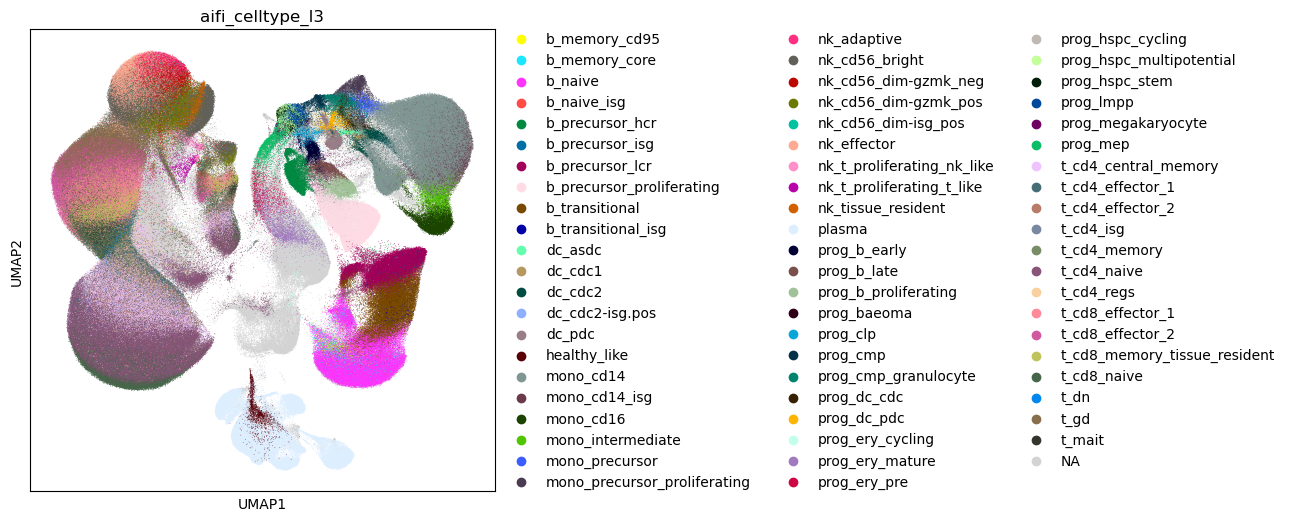

In [7]:
sc.pl.umap(adata, color=["aifi_celltype_l3"], size=1)

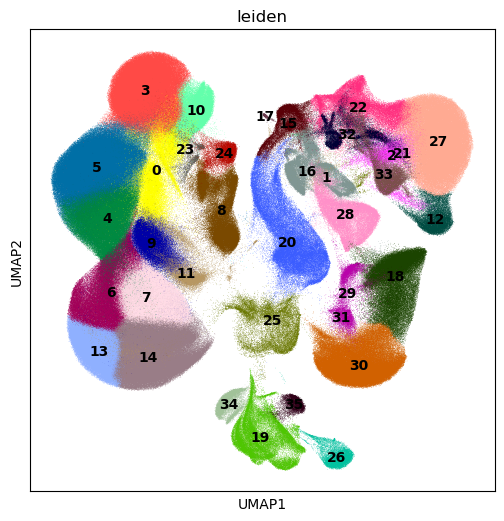

In [8]:
sc.pl.umap(adata, color=["leiden"], legend_loc="on data", size=0.5)

## 3. Subset cluster for further refinement

In [9]:
subset = adata[
    adata.obs["leiden"].isin(
        [
            "1",
            "2",
            "12",
            "15",
            "16",
            "17",
            "20",
            "21",
            "22",
            "25",
            "27",
            "28",
            "32",
            "33",
        ]
    )
]

In [10]:
# List of cell types to remove
remove_l3 = [
    "b_precursor_lcr",
    "plasma",
    "nk_t_proliferating_nk_like",
    "b_naive",
    "nk_cd56_bright",
    "nk_t_proliferating_t_like",
    "healthy_like",
    "t_cd4_central_memory",
    "t_cd8_effector_2",
    "t_cd8_memory_tissue_resident",
    "nk_cd56_dim-gzmk_pos",
    "t_cd8_effector_1",
    "t_cd4_memory",
    "t_gd",
    "b_memory_core",
    "b_transitional",
    "t_cd4_regs",
    "t_cd8_naive",
    "t_cd4_effector_1",
    "t_cd4_effector_2",
    "nk_tissue_resident",
    "nk_effector",
    "nk_cd56_dim-gzmk_neg",
    "nk_adaptive",
    "b_precursor_isg",
    "t_mait",
]

# Filter them out
subset = subset[~subset.obs["aifi_celltype_l3"].isin(remove_l3)].copy()

## 4. Process refinement object and view lineage markers

In [11]:
subset = process_adata(subset, resolution=2, run_harmony=True, run_rank_genes=True)

2025-08-06 22:55:49,996 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-06 22:56:03,678 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-06 22:56:04,804 - harmonypy - INFO - Iteration 1 of 10
2025-08-06 22:58:26,796 - harmonypy - INFO - Iteration 2 of 10
2025-08-06 23:00:48,828 - harmonypy - INFO - Iteration 3 of 10
2025-08-06 23:03:11,846 - harmonypy - INFO - Iteration 4 of 10
2025-08-06 23:05:43,689 - harmonypy - INFO - Iteration 5 of 10
2025-08-06 23:08:01,496 - harmonypy - INFO - Iteration 6 of 10
2025-08-06 23:10:30,193 - harmonypy - INFO - Iteration 7 of 10
2025-08-06 23:12:59,532 - harmonypy - INFO - Iteration 8 of 10
2025-08-06 23:15:12,605 - harmonypy - INFO - Converged after 8 iterations
/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/scanpy/tools/_tsne.py:126: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE 

In [12]:
sc.tl.dendrogram(subset, groupby="leiden")

sc.pl.dotplot(
    subset,
    var_names=[
        # Stem & early progenitor markers
        "CD34", "KIT", "FLT3", "HOXA9", "MEIS1", "LYL1", "TCF3", "GATA2",
        "IL7R", "DNTT", "RAG1", "RAG2", "PCNA", "MKI67", "TOP2A", "STMN1",

        # Erythroid lineage
        "GYPA", "HBA1", "HBB", "HBD", "AHSP", "ALAS2", "KLF1", "BCL11A", "FECH", "GATA1",

        # Megakaryocyte lineage
        "PF4", "PPBP", "ITGA2B", "GP1BA", "GP9", "MPL", "GATA1", "MEIS1", "CD34", "CSF1R", "CRYBG1",

        # Myeloid lineage
        "CEBPA", "CEBPD", "CSF1R", "CSF3R", "MPO", "LYZ", "IRF8", "SPI1",

        # Dendritic cells / monocyte-DC precursors
        "BATF3", "FCER1A", "CLEC9A", "CD1C",

        # B cell lineage
        "CD79A", "CD79B", "VPREB1", "IGLL1", "PAX5", "MS4A1", "MME",

        # T cell / lymphoid precursors
        "TCF3", "IL7R", "DNTT", "RAG1", "RAG2",

        # Stromal or supportive niche (likely contamination/background)
        "DCN", "COL1A2", "CXCL12", "VCAN",

        # Others/unassigned
        "AVP", "HES6"
    ],
    groupby="leiden",  # update to your relevant cluster key
    standard_scale="var",
    dendrogram=True,
    cmap="Reds",
    figsize=(22, 12),
    save='outlier_subset.png',
    show=False
)

{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

## 5. Annotate clusters based on marker plot

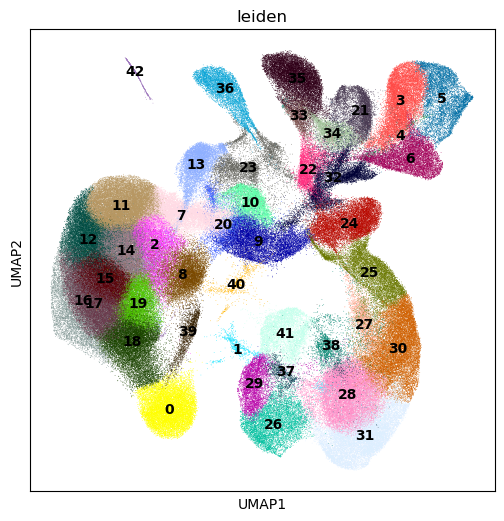

In [14]:
sc.pl.umap(
    subset, 
    color='leiden', 
    legend_loc='on data', 
    size=1
)

In [15]:
subset.obs['aifi_celltype_l3'] = subset.obs['aifi_celltype_l3'].cat.add_categories(
    "Exclude")

subset.obs.loc[
    subset.obs['leiden'].isin(
        ['1', '8', '20', '26', '27', '29', '32', '37', '38', '39', '40', '41', '42']),
    'aifi_celltype_l3'
] = 'Exclude'

subset = subset[subset.obs['aifi_celltype_l3'] != 'Exclude']

## 5. Classify clusters using KNN / PCA space

In [20]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X = subset.obsm["X_pca"]

labels = subset.obs["aifi_celltype_l3"].copy()
known = labels.notna()
unknown = labels.isna()

X = subset.obsm["X_pca"]
knn = KNeighborsClassifier(n_neighbors=100, weights="distance", n_jobs=-1)
knn.fit(X[known], labels[known])

subset.obs["aifi_celltype_l3_knn"] = labels
subset.obs.loc[unknown, "aifi_celltype_l3_knn"] = knn.predict(X[unknown])

/tmp/ipykernel_7238/3738856579.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  subset.obs["aifi_celltype_l3_knn"] = labels


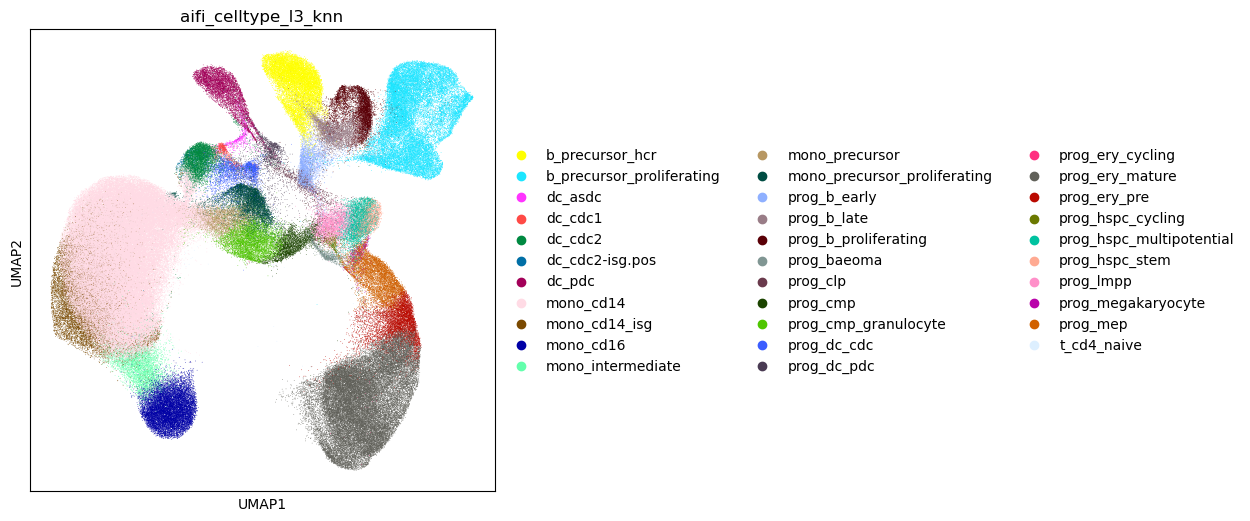

In [21]:
sc.pl.umap(subset, color=['aifi_celltype_l3_knn'], size=1)

In [22]:
subset.obs.loc[
    subset.obs['leiden'].isin(['28', '31']),
    'aifi_celltype_l3_knn'
] = 'prog_ery_cycling'

subset.obs.loc[
    subset.obs['leiden'].isin(['13']),
    'aifi_celltype_l3_knn'
] = 'dc_cdc2'

## 6. Add labels back to the main object

In [23]:
adata.obs = adata.obs.merge(subset.obs[['aifi_celltype_l3_knn']], on="barcodes", how="left")

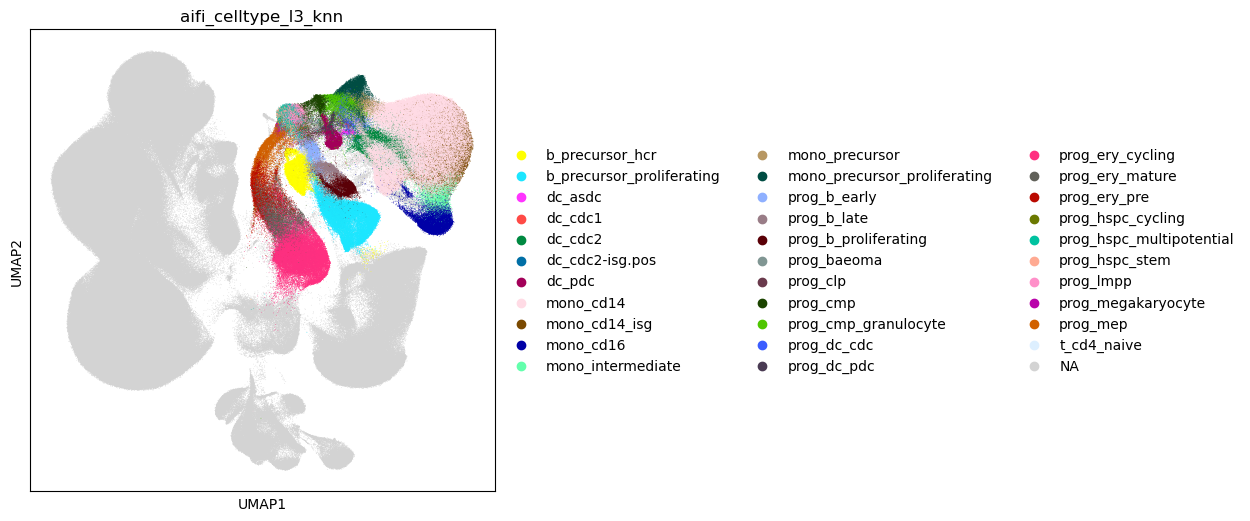

In [25]:
sc.pl.umap(adata, color=['aifi_celltype_l3_knn'], size=1)

In [26]:
mask = adata.obs['aifi_celltype_l3_knn'].notna()
adata.obs.loc[mask, 'aifi_celltype_l3'] = adata.obs.loc[mask, 'aifi_celltype_l3_knn'].astype(str)
adata.obs['aifi_celltype_l3'] = adata.obs['aifi_celltype_l3'].astype('category').cat.remove_unused_categories()

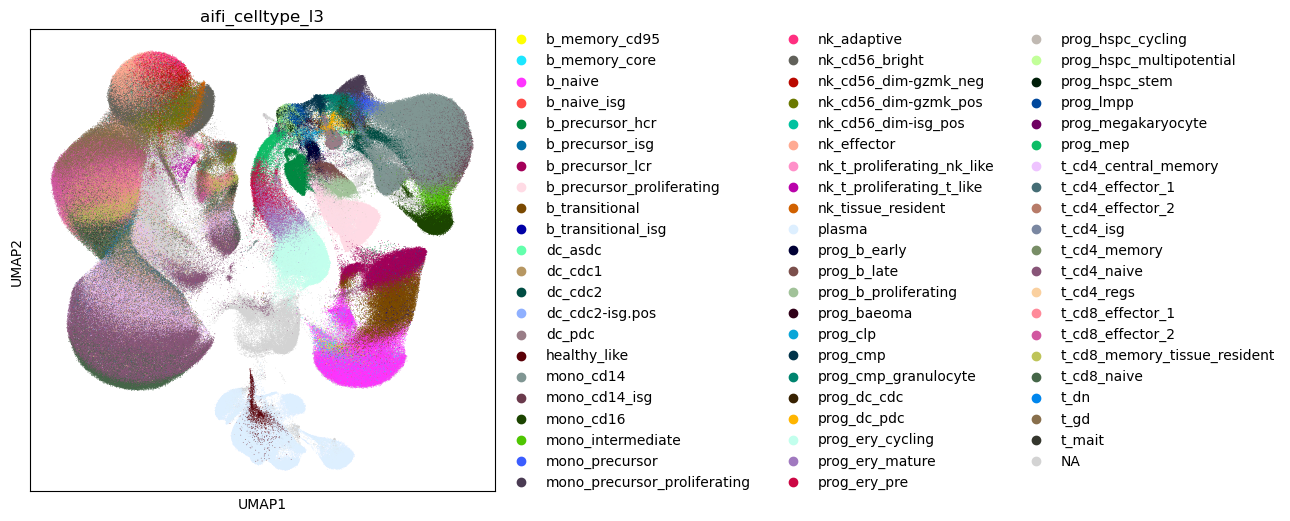

In [27]:
sc.pl.umap(adata, color=['aifi_celltype_l3'], size=1)

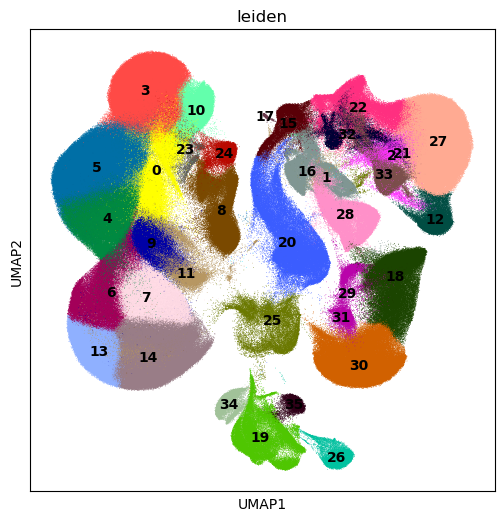

In [28]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', size=1)

> Drop some of the true junky junk

In [29]:
adata = adata[adata.obs['leiden'] != '25']
adata = adata[adata.obs['leiden'] != '17']

## 7. Ugh back to T & NK cells

In [30]:
adata.obs['t_nk'] = False
adata.obs.loc[
    adata.obs['leiden'].isin([
        "0",
            "3",
            "4",
            "5",
            "6",
            "7",
            "8",
            "9",
            "10",
            "11",
            "13",
            "14",
            "23",
            "24"
    ]), 
    't_nk'
] =  True

/tmp/ipykernel_7238/1264091622.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['t_nk'] = False


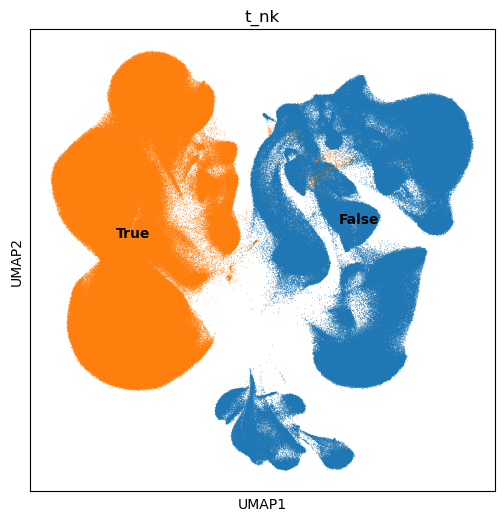

In [31]:
sc.pl.umap(adata, color=['t_nk'], legend_loc='on data', size=1)

In [32]:
adata.shape

(1437195, 33538)

In [33]:
subset = adata.obs[adata.obs['t_nk'] == True]
mask = subset[subset['aifi_celltype_l3'].isna()].index
mask_bool = adata.obs.index.isin(mask)

adata = adata[~mask_bool]

In [34]:
adata.shape

(1242439, 33538)

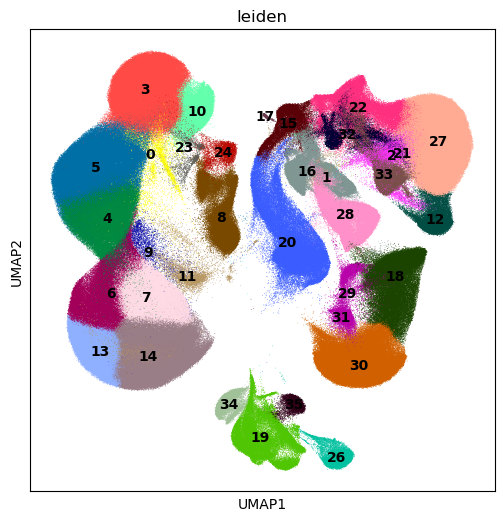

In [37]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', size=1)

## 8. Clean up again using the KNN

In [42]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X = adata.obsm["X_pca"]

labels = adata.obs["aifi_celltype_l3"].copy()
known = labels.notna()
unknown = labels.isna()

X = adata.obsm["X_pca"]
knn = KNeighborsClassifier(n_neighbors=100, weights="distance", n_jobs=-1)
knn.fit(X[known], labels[known])

adata.obs["aifi_celltype_l3_knn"] = labels
adata.obs.loc[unknown, "aifi_celltype_l3_knn"] = knn.predict(X[unknown])

/tmp/ipykernel_7238/8049801.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["aifi_celltype_l3_knn"] = labels


In [48]:
adata.obs['aifi_celltype_l3_knn'] = adata.obs['aifi_celltype_l3_knn'].replace('healthy_like', 'plasma_healthy_like')

## 9. Backprop L3 to L2

In [53]:
l3_to_l2 = {
    't_gd': 't_gd',
    'mono_cd16': 'mono_cd16',
    'b_precursor_proliferating': 'b_precursor',
    't_cd4_central_memory': 't_cd4_memory',
    'mono_cd14': 'mono_cd14',
    't_cd8_effector_2': 't_cd8_effector',
    't_cd4_naive': 't_cd4_naive',
    'nk_effector': 'nk_effector',
    'b_precursor_lcr': 'b_precursor',
    'b_transitional': 'b_transitional',
    'prog_b_late': 'prog_b',
    't_cd4_regs': 't_cd4_regs',
    'nk_cd56_dim-gzmk_neg': 'nk_cd56_dim',
    'prog_clp': 'prog_clp',
    't_cd8_memory_tissue_resident': 't_cd8_memory',
    'mono_cd14_isg': 'mono_cd14',
    'b_naive': 'b_naive',
    't_cd8_effector_1': 't_cd8_effector',
    't_mait': 't_mait',
    'b_precursor_hcr': 'b_precursor',
    'dc_pdc': 'dc_pdc',
    'mono_precursor_proliferating': 'mono_precursor',
    'nk_cd56_bright': 'nk_cd56_bright',
    'dc_cdc1': 'dc_cdc',
    'mono_intermediate': 'mono_intermediate',
    'nk_cd56_dim-isg_pos': 'nk_cd56_dim',
    'nk_tissue_resident': 'nk_cd56_dim',
    'prog_dc_cdc': 'prog_dc',
    'dc_asdc': 'dc_asdc',
    'prog_mep': 'prog_mep',
    't_cd4_effector_2': 't_cd4_effector',
    'nk_cd56_dim-gzmk_pos': 'nk_cd56_dim',
    'prog_b_proliferating': 'prog_b',
    't_cd4_memory': 't_cd4_memory',
    'prog_ery_mature': 'prog_ery_mature',
    'plasma_healthy_like': 'plasma_healthy_like',
    't_cd8_naive': 't_cd8_naive',
    'dc_cdc2': 'dc_cdc2',
    't_cd4_isg': 't_cd4_naive',
    'nk_adaptive': 'nk_cd56_dim',
    't_cd4_effector_1': 't_cd4_effector',
    'prog_cmp_granulocyte': 'prog_cmp',
    'prog_lmpp': 'prog_lmpp',
    'prog_dc_pdc': 'prog_dc',
    'b_memory_cd95': 'b_memory',
    'dc_cdc2-isg.pos': 'dc_cdc',
    'mono_precursor': 'mono_precursor',
    't_dn': 't_dn',
    'prog_b_early': 'prog_b',
    'prog_hspc_multipotential': 'prog_hspc',
    'prog_megakaryocyte': 'prog_megakaryocyte',
    'nk_t_proliferating_nk_like': 'nk_t_proliferating',
    'prog_ery_pre': 'prog_ery',
    'prog_baeoma': 'prog_baeoma',
    'nk_t_proliferating_t_like': 'nk_t_proliferating',
    'b_transitional_isg': 'b_transitional',
    'prog_cmp': 'prog_cmp',
    'b_precursor_isg': 'b_precursor',
    'prog_ery_cycling': 'prog_ery_mature',
    'prog_hspc_stem': 'prog_hspc',
    'b_memory_core': 'b_memory',
    'b_naive_isg': 'b_naive',
    'prog_hspc_cycling': 'prog_hspc',
    'plasma': 'plasma'
}

adata.obs['aifi_celltype_l2_knn'] = adata.obs['aifi_celltype_l3_knn'].map(l3_to_l2).astype('category').cat.remove_unused_categories()

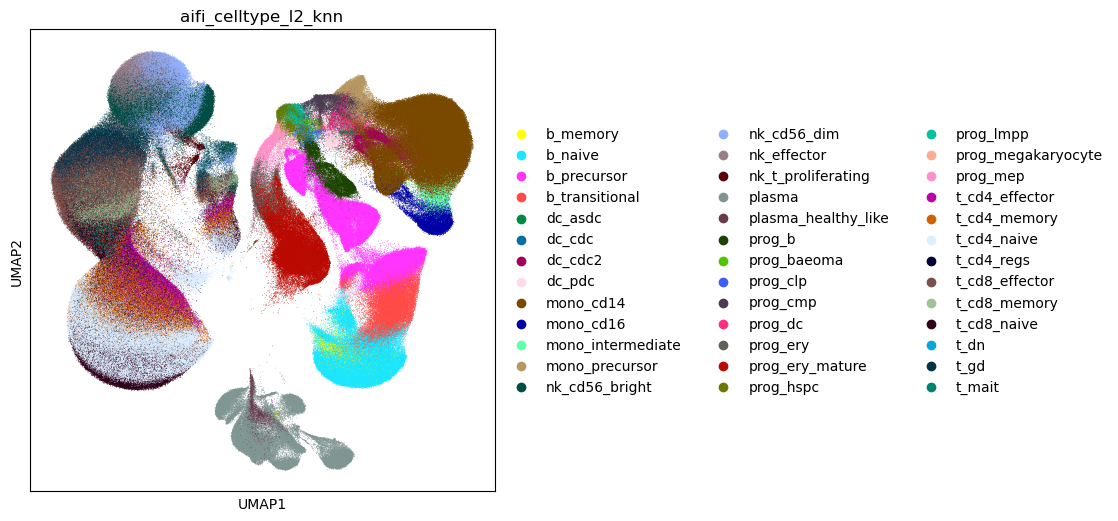

In [54]:
sc.pl.umap(adata, color=['aifi_celltype_l2_knn'], size=1)

## 9. And then L2 to L1

In [61]:
l2_to_l1 = celltype_dict = {
    'b_memory': 'b_cell',
    'b_naive': 'b_cell',
    'b_precursor': 'b_cell',
    'b_transitional': 'b_cell',
    'dc_asdc': 'dc',
    'dc_cdc': 'dc',
    'dc_cdc2': 'dc',
    'dc_pdc': 'dc',
    'mono_cd14': 'monocyte',
    'mono_cd16': 'monocyte',
    'mono_intermediate': 'monocyte',
    'mono_precursor': 'monocyte',
    'nk_cd56_bright': 'nk_cell',
    'nk_cd56_dim': 'nk_cell',
    'nk_effector': 'nk_cell',
    'nk_t_proliferating': 'nk_cell',
    'plasma': 'plasma',
    'plasma_healthy_like': 'plasma',
    'prog_b': 'progenitor',
    'prog_baeoma': 'progenitor',
    'prog_clp': 'progenitor',
    'prog_cmp': 'progenitor',
    'prog_dc': 'progenitor',
    'prog_ery': 'progenitor',
    'prog_ery_mature': 'progenitor',
    'prog_hspc': 'progenitor',
    'prog_lmpp': 'progenitor',
    'prog_megakaryocyte': 'progenitor',
    'prog_mep': 'progenitor',
    't_cd4_effector': 't_cell',
    't_cd4_memory': 't_cell',
    't_cd4_naive': 't_cell',
    't_cd4_regs': 't_cell',
    't_cd8_effector': 't_cell',
    't_cd8_memory': 't_cell',
    't_cd8_naive': 't_cell',
    't_dn': 't_cell',
    't_gd': 't_cell',
    't_mait': 't_cell'
}

adata.obs['aifi_celltype_l1_knn'] = adata.obs['aifi_celltype_l2_knn'].map(l2_to_l1).astype('category').cat.remove_unused_categories()

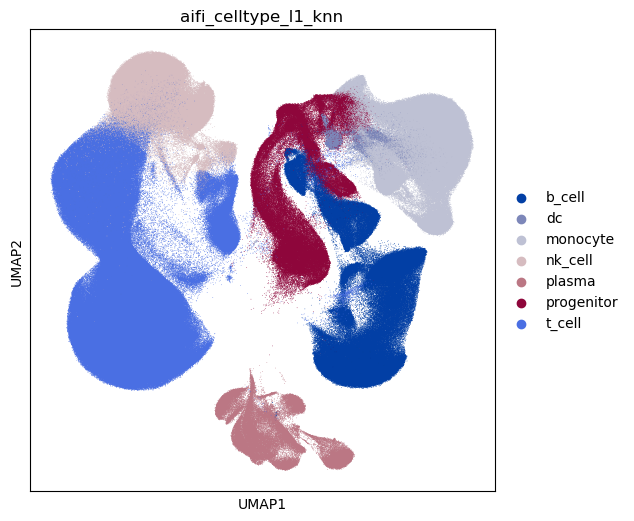

In [62]:
sc.pl.umap(adata, color=['aifi_celltype_l1_knn'], size=1)

## 10. Save the work of art

In [64]:
adata.write('../../../data/rna/bmmc-outliers/bmmc-refined-labels.h5ad')

## 11. Final per cell counts

In [77]:
adata.obs[['aifi_celltype_l1_knn', 'manual.category']].value_counts(ascending=True)

aifi_celltype_l1_knn  manual.category
plasma                healthy_bmmc          414
dc                    healthy_bmmc         2268
nk_cell               healthy_bmmc         5328
progenitor            healthy_bmmc         7975
b_cell                healthy_bmmc         9067
dc                    tumor_bmmc          13280
monocyte              healthy_bmmc        17579
t_cell                healthy_bmmc        36437
plasma                tumor_bmmc          55837
progenitor            tumor_bmmc          91499
nk_cell               tumor_bmmc         122555
monocyte              tumor_bmmc         136935
b_cell                tumor_bmmc         179375
t_cell                tumor_bmmc         563343
dtype: int64

In [84]:
pd.set_option('display.max_rows', None)
adata.obs[['aifi_celltype_l2_knn', 'manual.category']].value_counts().sort_index()

aifi_celltype_l2_knn  manual.category
b_memory              healthy_bmmc          552
                      tumor_bmmc           6776
b_naive               healthy_bmmc         6291
                      tumor_bmmc          72690
b_precursor           healthy_bmmc         1863
                      tumor_bmmc          75278
b_transitional        healthy_bmmc          361
                      tumor_bmmc          24631
dc_asdc               healthy_bmmc           32
                      tumor_bmmc            580
dc_cdc                healthy_bmmc           17
                      tumor_bmmc            172
dc_cdc2               healthy_bmmc         1206
                      tumor_bmmc           8056
dc_pdc                healthy_bmmc         1013
                      tumor_bmmc           4472
mono_cd14             healthy_bmmc        16029
                      tumor_bmmc         110848
mono_cd16             healthy_bmmc          592
                      tumor_bmmc          13033
mo

In [85]:
pd.reset_option('display.max_rows')